# Fundamentals of Machine Learning — Exercise 4

## Hierarchical Clustering, DBSCAN, and Choosing a Clustering Method

In Exercise 3, K-means showed us that clustering depends on representation, distance, scaling, and the chosen number of clusters.

This exercise asks a new question:

> **What should we do when clusters are not compact, spherical groups around a centroid?**

We will compare:

- **K-means**,
- **agglomerative hierarchical clustering**,
- **DBSCAN**.

The classroom workflow remains:

> **question → prediction → computation → visualisation → interpretation → verification**

### Learning outcomes

After completing this exercise, you should be able to:

- explain the bottom-up idea of agglomerative clustering,
- read a dendrogram and explain what a horizontal cut represents,
- distinguish single, complete, and Ward linkage,
- explain the roles of `eps` and `min_samples` in DBSCAN,
- identify core points, border points, and noise,
- compare clustering methods according to data geometry and noise,
- recognise that one numerical metric cannot decide every clustering problem,
- justify a clustering method using several pieces of evidence,
- use an AI chatbot to question a decision after forming your own answer.

**Recommended duration:** 100–120 minutes.  
The final method-selection memo may be completed as homework.

## How to work in this exercise

Most code is already prepared. Your task is to:

1. **predict** the result before running a cell,
2. **change** only clearly marked settings,
3. **compare** alternative methods,
4. **interpret** the output using numerical and visual evidence,
5. **verify** an important claim with a second piece of evidence.

Do not choose a method only because its plot “looks nice”.  
A defensible conclusion should mention:

- the expected cluster shape,
- the role of distance or density,
- sensitivity to noise,
- at least one numerical result,
- one limitation.

## 0. Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.datasets import make_blobs, make_moons, make_circles, load_wine
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 12

## 1. The same number of groups can have different geometry

We begin with three artificial datasets. Each dataset contains **two known generating groups**, but the shapes are different.

Before running the cell, predict which dataset should be easiest for K-means.

| Dataset | Expected shape | Will K-means work well? Why? |
|---|---|---|
| Compact blobs |  |  |
| Two moons |  |  |
| Concentric circles |  |  |

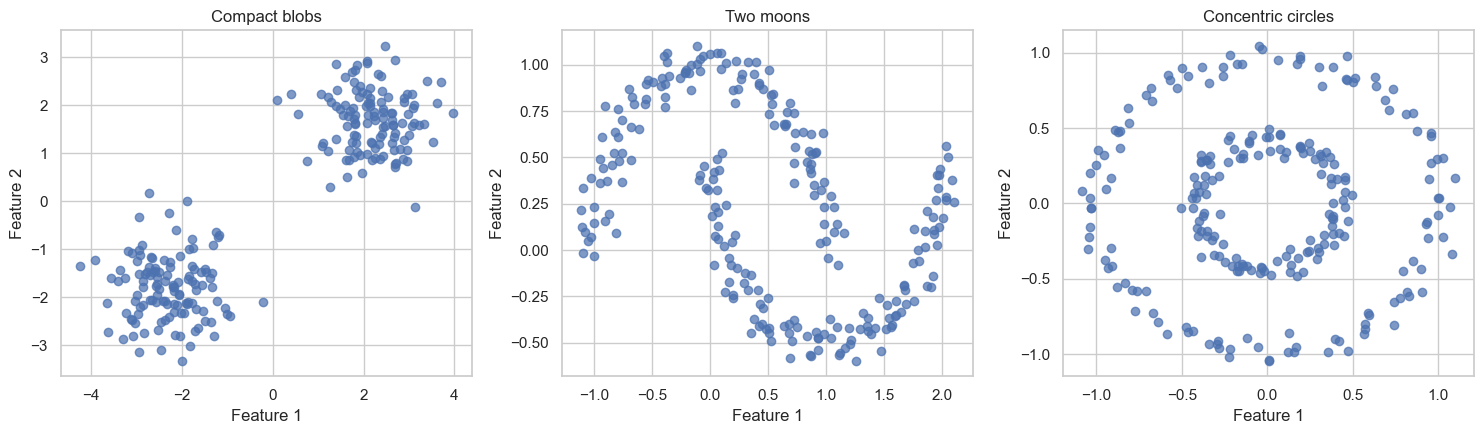

In [3]:
X_blobs, y_blobs = make_blobs(
    n_samples=240,
    centers=[(-2.2, -1.7), (2.2, 1.7)],
    cluster_std=[0.65, 0.70],
    random_state=RANDOM_STATE,
)

X_moons, y_moons = make_moons(
    n_samples=240,
    noise=0.07,
    random_state=RANDOM_STATE,
)

X_circles, y_circles = make_circles(
    n_samples=240,
    factor=0.42,
    noise=0.05,
    random_state=RANDOM_STATE,
)

toy_sets = {
    "Compact blobs": (X_blobs, y_blobs),
    "Two moons": (X_moons, y_moons),
    "Concentric circles": (X_circles, y_circles),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for axis, (name, (X, _)) in zip(axes, toy_sets.items()):
    axis.scatter(X[:, 0], X[:, 1], alpha=0.72)
    axis.set_title(name)
    axis.set_xlabel("Feature 1")
    axis.set_ylabel("Feature 2")

plt.tight_layout()
plt.show()

## Reading: Silhouette Score (5 min)

When we create clusters, we need some way to evaluate whether the clustering is good.

One commonly used measure is the **silhouette score**.

The silhouette score compares two things for each sample:

1. How close the sample is to other samples in the **same cluster**.
2. How close the sample is to samples in the **nearest different cluster**.

For a sample $i$, let:

$$
a(i) = \text{average distance from } i \text{ to other samples in its own cluster}
$$

and

$$
b(i) = \text{smallest average distance from } i \text{ to samples in another cluster}
$$

The silhouette value of sample $i$ is then:

$$
s(i)=\frac{b(i)-a(i)}{\max(a(i),b(i))}
$$

The value is always between $-1$ and $1$.

### How to interpret it

- **Close to 1**  
  The sample is much closer to its own cluster than to neighbouring clusters.  
  This indicates a good assignment.

- **Close to 0**  
  The sample lies close to a boundary between two clusters.

- **Below 0**  
  The sample may be assigned to the wrong cluster because it is closer to another cluster than to its own.

The overall **silhouette score** is the average silhouette value over all samples.

### Example

Suppose for one sample:

$$
a(i)=2
$$

and

$$
b(i)=6
$$

Then:

$$
s(i)=\frac{6-2}{6}\approx 0.67
$$

This suggests that the sample fits its current cluster reasonably well.

### What does a high silhouette score mean?

A high silhouette score usually indicates clusters that are:

- **compact** - samples within the same cluster are close to each other,
- **well separated** - different clusters are far from each other.

However, a higher silhouette score does **not always mean that the clustering is the most meaningful one**.

For example, a clustering method may create compact groups with a high silhouette score while failing to capture the actual geometric structure of the data.

> **Key idea:** The silhouette score measures compactness and separation, not whether the discovered clusters are meaningful for the problem.

### Run the same K-means model on all three datasets

The value `k=2` is deliberately kept constant. The question is not whether we supplied the correct number of clusters, but whether the **model assumption** fits the geometry.

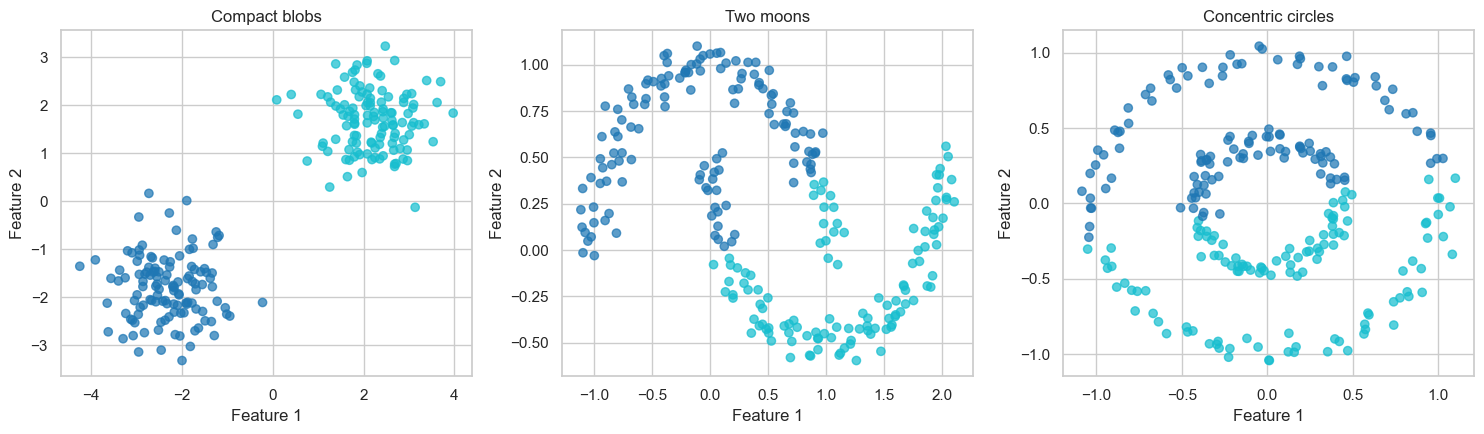

,labels,ARI against generating groups,silhouette
Compact blobs,"[0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, ...",1.0,0.785946
Two moons,"[0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, ...",0.487863,0.491559
Concentric circles,"[0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, ...",-0.003922,0.338079


In [4]:
kmeans_results = {}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for axis, (name, (X, true_group)) in zip(axes, toy_sets.items()):
    X_scaled = StandardScaler().fit_transform(X)

    labels = KMeans(
        n_clusters=2,
        n_init=20,
        random_state=42,
    ).fit_predict(X_scaled)

    kmeans_results[name] = {
        "labels": labels,
        "ARI against generating groups": adjusted_rand_score(true_group, labels),
        "silhouette": silhouette_score(X_scaled, labels),
    }

    axis.scatter(X[:, 0], X[:, 1], c=labels, cmap="tab10", alpha=0.72)
    axis.set_title(name)
    axis.set_xlabel("Feature 1")
    axis.set_ylabel("Feature 2")

plt.tight_layout()
plt.show()

pd.DataFrame(kmeans_results).T.round(3)

### Activity 1 — Explain a failure, not only a score

Complete the argument:

> K-means performs well on __________ because __________.
>
> K-means fails on __________ even though `k=2`, because __________.
>
> The failure is caused mainly by the method's assumption that __________.

Why is “the algorithm found two clusters” insufficient evidence that the partition is meaningful?

## 2. Agglomerative clustering: building a hierarchy of merges

Agglomerative clustering is a **bottom-up** procedure:

1. each observation starts as its own cluster,
2. the closest pair of clusters is merged,
3. distances between the new clusters are recomputed,
4. merging continues until only one cluster remains.

A dendrogram records this process.

- Leaves at the bottom represent observations.
- A horizontal connection represents a merge.
- The height of a merge represents the dissimilarity at which it occurred.
- A horizontal cut converts the hierarchy into a chosen partition.

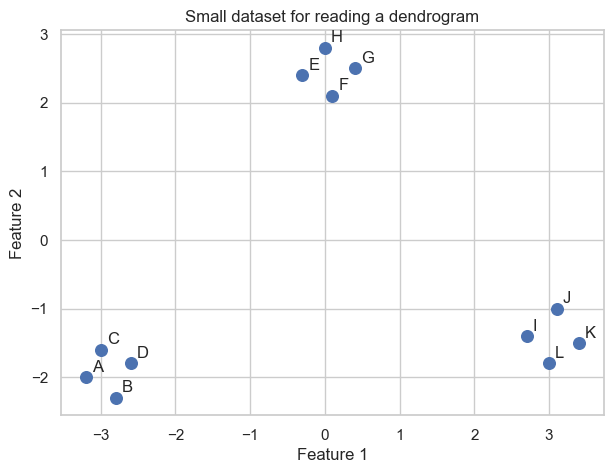

In [5]:
X_small = np.array([
    [-3.2, -2.0], [-2.8, -2.3], [-3.0, -1.6], [-2.6, -1.8],
    [-0.3,  2.4], [ 0.1,  2.1], [ 0.4,  2.5], [ 0.0,  2.8],
    [ 2.7, -1.4], [ 3.1, -1.0], [ 3.4, -1.5], [ 3.0, -1.8],
])
point_names = list("ABCDEFGHIJKL")

plt.figure(figsize=(7, 5))
plt.scatter(X_small[:, 0], X_small[:, 1], s=70)

for name, (x, y) in zip(point_names, X_small):
    plt.text(x + 0.08, y + 0.08, name)

plt.title("Small dataset for reading a dendrogram")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

### Predict before viewing the dendrogram

1. Which points do you expect to merge first?
2. Which three broad groups do you see?
3. At approximately what stage should the algorithm begin merging genuinely different groups?

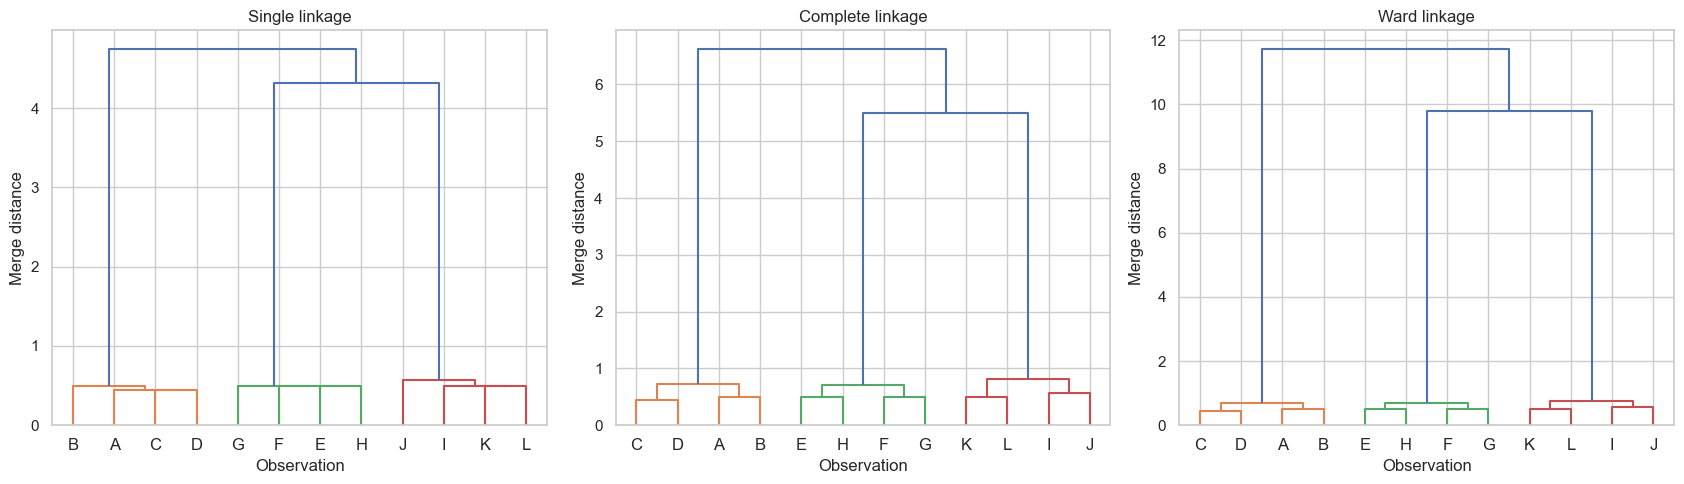

In [6]:
linkage_methods = ["single", "complete", "ward"]
small_linkages = {
    method: linkage(X_small, method=method)
    for method in linkage_methods
}

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for axis, method in zip(axes, linkage_methods):
    dendrogram(
        small_linkages[method],
        labels=point_names,
        ax=axis,
    )
    axis.set_title(f"{method.capitalize()} linkage")
    axis.set_xlabel("Observation")
    axis.set_ylabel("Merge distance")

plt.tight_layout()
plt.show()

### Activity 2 — Read the hierarchy

Choose one dendrogram and answer:

1. Name one pair of observations that merges early.
2. Identify one large vertical gap.
3. What number of clusters would a cut inside that gap produce?

### Change the cut, not the hierarchy

The complete hierarchy remains fixed. We now choose a horizontal cut.

Change only `CUT_HEIGHT` and observe the number of clusters.

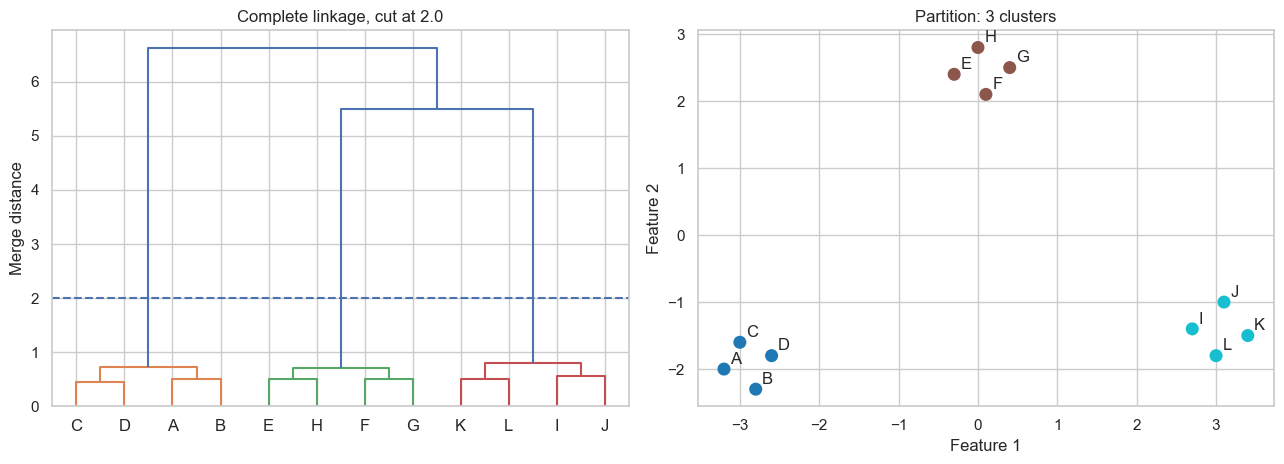

In [22]:
CUT_HEIGHT = 2.0

complete_labels = fcluster(
    small_linkages["complete"],
    t=CUT_HEIGHT,
    criterion="distance",
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

dendrogram(
    small_linkages["complete"],
    labels=point_names,
    ax=axes[0],
)
axes[0].axhline(CUT_HEIGHT, linestyle="--")
axes[0].set_title(f"Complete linkage, cut at {CUT_HEIGHT}")
axes[0].set_ylabel("Merge distance")

axes[1].scatter(
    X_small[:, 0],
    X_small[:, 1],
    c=complete_labels,
    cmap="tab10",
    s=70,
)
for name, (x, y) in zip(point_names, X_small):
    axes[1].text(x + 0.08, y + 0.08, name)
axes[1].set_title(
    f"Partition: {pd.Series(complete_labels).nunique()} clusters"
)
axes[1].set_xlabel("Feature 1")
axes[1].set_ylabel("Feature 2")

plt.tight_layout()
plt.show()

### Stop and explain

Complete the sentences:

> Moving the cut **upward** usually produces __________ clusters because __________.
>
> Moving the cut **downward** usually produces __________ clusters because __________.
>
> Choosing a cut is still a modelling decision because __________.

## 3. Linkage changes what “closest clusters” means - 5 min reading

In **agglomerative hierarchical clustering**, we repeatedly merge the two closest clusters.

The important question is:

> **How do we define the distance between two clusters?**

This is determined by the **linkage method**.

### Single linkage

Single linkage uses the distance between the **closest pair of points** from the two clusters.

$$
d(A,B)=\min_{a\in A,\;b\in B} d(a,b)
$$

This method can find elongated or irregularly shaped clusters.

Its main disadvantage is the **chaining effect**: two clusters can be connected by a sequence of nearby points even if their overall shapes are quite different.

### Complete linkage

Complete linkage uses the distance between the **most distant pair of points** from the two clusters.

$$
d(A,B)=\max_{a\in A,\;b\in B} d(a,b)
$$

Compared with single linkage, it usually prefers more **compact clusters**.

It is less affected by chaining, but distant points and outliers can strongly influence the result.

### Ward linkage

Ward linkage uses a different idea.

Instead of comparing the closest or farthest points, it merges the two clusters that cause the **smallest increase in within-cluster variability**.

The goal is to keep the clusters as compact as possible.

Conceptually, Ward linkage is similar to K-means because both approaches prefer clusters whose points are close to their cluster centre.

### Quick comparison

| Linkage | Main idea | Typical effect |
|---|---|---|
| **Single** | Closest pair of points | Can find irregular shapes, but may create chains |
| **Complete** | Farthest pair of points | Prefers compact clusters |
| **Ward** | Smallest increase in within-cluster variance | Prefers compact, relatively balanced clusters |

### Key idea

The linkage method can strongly change the final clustering, even when the data and the distance metric stay the same.

Before running the next cell, predict which linkage is most likely to follow the curved moons.

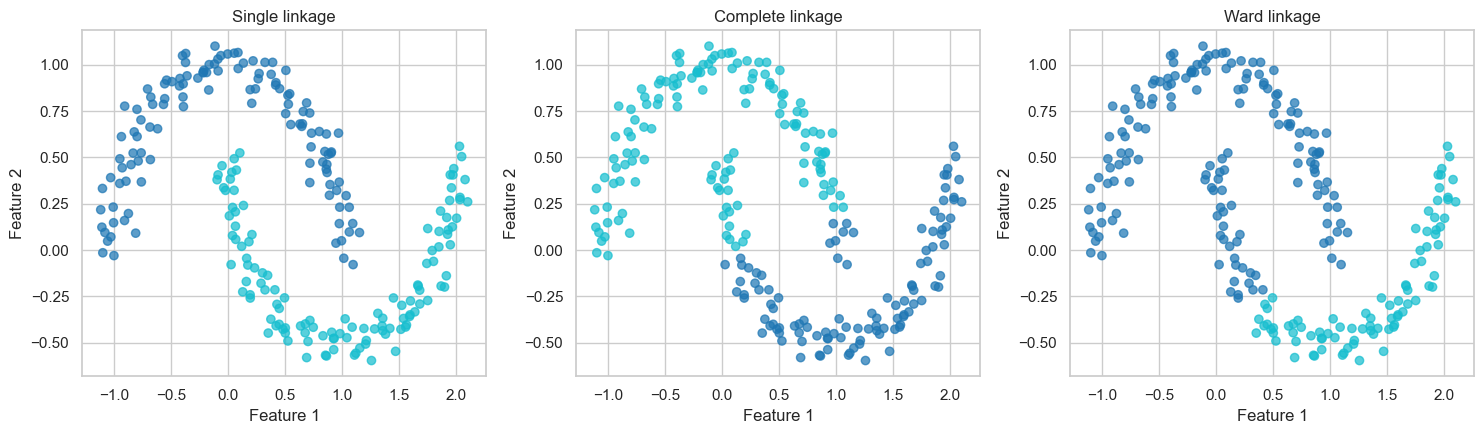

,silhouette,ARI against generating groups
single,0.370,1.000
complete,0.484,0.573
ward,0.441,0.512


In [8]:
X_moons_scaled = StandardScaler().fit_transform(X_moons)

moon_linkage_results = {}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for axis, method in zip(axes, linkage_methods):
    labels = AgglomerativeClustering(
        n_clusters=2,
        linkage=method,
    ).fit_predict(X_moons_scaled)

    moon_linkage_results[method] = {
        "silhouette": silhouette_score(X_moons_scaled, labels),
        "ARI against generating groups": adjusted_rand_score(y_moons, labels),
    }

    axis.scatter(
        X_moons[:, 0],
        X_moons[:, 1],
        c=labels,
        cmap="tab10",
        alpha=0.72,
    )
    axis.set_title(f"{method.capitalize()} linkage")
    axis.set_xlabel("Feature 1")
    axis.set_ylabel("Feature 2")

plt.tight_layout()
plt.show()

pd.DataFrame(moon_linkage_results).T.round(3)

### Activity 3 — Link the result to the definition

1. Which linkage best follows the two moons?
2. Explain the result using the definition of that linkage.
3. Which method creates more compact groups?
4. What risk might arise if a few points form a thin “bridge” between two groups?

## 4. DBSCAN: clusters as dense regions - 5 min reading

**DBSCAN** stands for **Density-Based Spatial Clustering of Applications with Noise**.

Unlike K-means or hierarchical clustering, DBSCAN does not try to create compact spherical groups. Instead, it looks for **dense regions of points** separated by areas with low density.

DBSCAN uses two main parameters:

- **`eps`** - the maximum distance within which two points are considered neighbours,
- **`min_samples`** - the minimum number of nearby points required to form a dense region.

### Types of points

DBSCAN distinguishes three types of samples:

- **Core point**  
  A point that has at least `min_samples` points in its `eps` neighbourhood.

- **Border point**  
  A point that does not have enough neighbours to be a core point, but lies close to a core point.

- **Noise point**  
  A point that does not belong to any dense region.

In scikit-learn, noise points are usually assigned the label:

```python
-1
```

### How does DBSCAN create clusters?

DBSCAN starts from a core point and adds neighbouring points to the same cluster.

If one of these neighbours is also a core point, its neighbourhood is added as well.

The cluster therefore continues to **expand through connected dense regions**.

This allows DBSCAN to detect clusters with complex shapes.

### Why is DBSCAN useful?

DBSCAN has several important advantages:

- the number of clusters does **not** have to be specified in advance,
- it can find clusters with **irregular shapes**,
- it can identify **noise and outliers**.

This makes it especially useful for datasets such as **two moons**, where compact spherical clusters are not a good assumption.

### Choosing the parameters

The result strongly depends on `eps` and `min_samples`.

If `eps` is too small:

- many points may be classified as noise,
- clusters may break into smaller pieces.

If `eps` is too large:

- separate clusters may become connected,
- DBSCAN may merge them into one large cluster.

### Key idea

> **DBSCAN defines clusters as connected regions of high point density and treats isolated points as noise.**

This is fundamentally different from methods such as K-means, which define clusters mainly through distance to cluster centres.

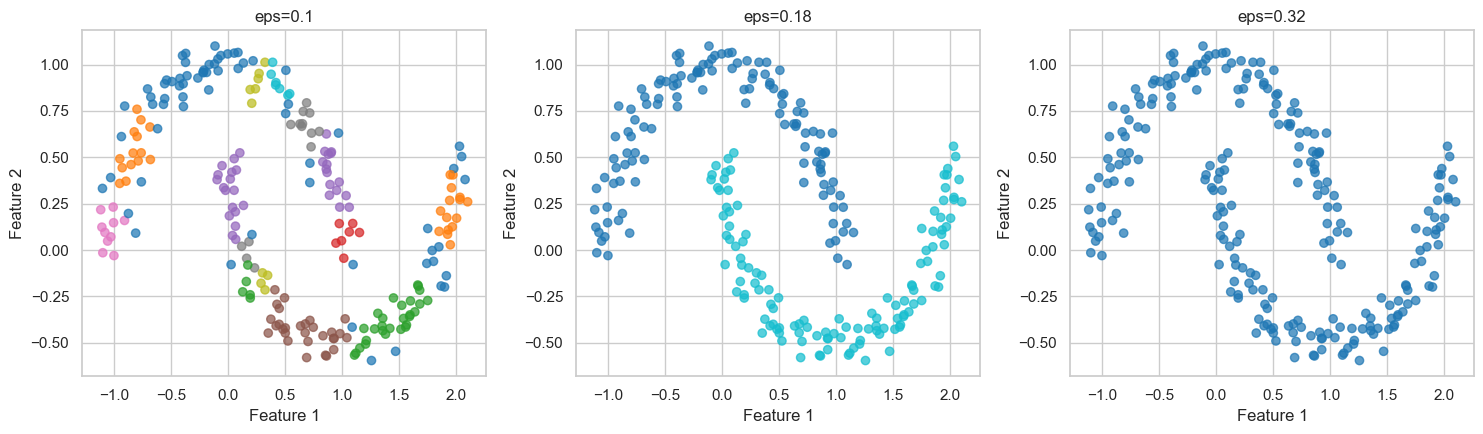

,eps,clusters excluding noise,noise points,silhouette excluding noise,ARI against generating groups
0,0.10,17,38,0.461,0.113
1,0.18,2,0,0.317,1.000
2,0.32,1,0,NaN,0.000


In [24]:
EPS_VALUES = [0.10, 0.18, 0.32]
dbscan_rows = []

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for axis, eps in zip(axes, EPS_VALUES):
    labels = DBSCAN(
        eps=eps,
        min_samples=5,
    ).fit_predict(X_moons)

    non_noise = labels != -1
    n_clusters = len(set(labels[non_noise]))

    if n_clusters >= 2 and non_noise.sum() > n_clusters:
        silhouette = silhouette_score(
            X_moons[non_noise],
            labels[non_noise],
        )
    else:
        silhouette = np.nan

    dbscan_rows.append({
        "eps": eps,
        "clusters excluding noise": n_clusters,
        "noise points": int((labels == -1).sum()),
        "silhouette excluding noise": silhouette,
        "ARI against generating groups": adjusted_rand_score(y_moons, labels),
    })

    axis.scatter(
        X_moons[:, 0],
        X_moons[:, 1],
        c=labels,
        cmap="tab10",
        alpha=0.72,
    )
    axis.set_title(f"eps={eps}")
    axis.set_xlabel("Feature 1")
    axis.set_ylabel("Feature 2")

plt.tight_layout()
plt.show()

pd.DataFrame(dbscan_rows).round(3)

### Activity 4 - Explain parameter sensitivity

For each value of `eps`, describe what happened.

Then complete:

> A very small `eps` can create many small clusters or noise because __________.
>
> A very large `eps` can merge distinct groups because __________.
>
> Therefore, DBSCAN does not remove parameter choice; it changes the question from “how many clusters?” to __________.

### Core, border, and noise points

We now inspect the selected DBSCAN solution directly.

core      238
border      2
Name: count, dtype: int64

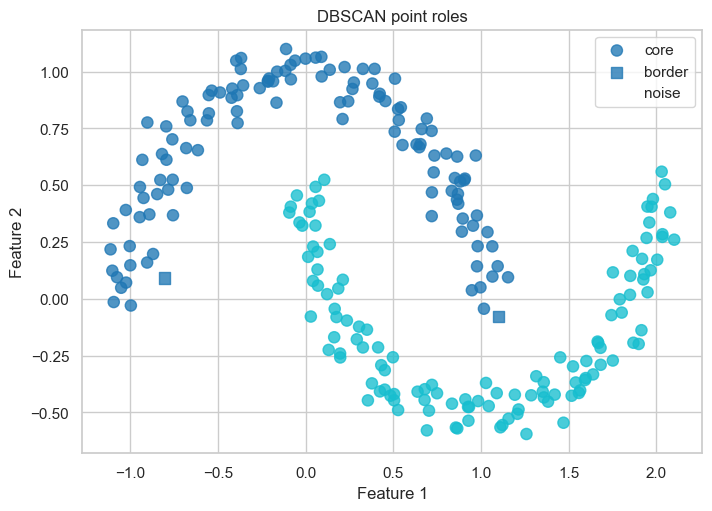

In [25]:
selected_dbscan = DBSCAN(
    eps=0.18,
    min_samples=5,
).fit(X_moons)

selected_labels = selected_dbscan.labels_

core_mask = np.zeros(len(X_moons), dtype=bool)
core_mask[selected_dbscan.core_sample_indices_] = True

point_role = np.full(len(X_moons), "border", dtype=object)
point_role[core_mask] = "core"
point_role[selected_labels == -1] = "noise"

role_counts = pd.Series(point_role).value_counts()
display(role_counts)

plt.figure(figsize=(8, 5.5))

for role, marker in [("core", "o"), ("border", "s"), ("noise", "x")]:
    mask = point_role == role
    plt.scatter(
        X_moons[mask, 0],
        X_moons[mask, 1],
        c=selected_labels[mask],
        cmap="tab10",
        marker=marker,
        s=65,
        alpha=0.78,
        label=role,
    )

plt.title("DBSCAN point roles")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

### Stop and explain

Why is a border point allowed to belong to a cluster even though its own neighbourhood is not dense enough?

Why is the label `-1` different from an ordinary cluster number?

## 5. Compare methods systematically

We now apply several methods to all three geometries.

For this controlled experiment:

- each dataset is standardised,
- methods that require a cluster count receive `2`,
- DBSCAN uses `eps=0.40` and `min_samples=5`,
- the generating groups are used only as an **external audit**.

In [27]:
def count_clusters(labels):
    labels = np.asarray(labels)
    return len(set(labels[labels != -1]))

def silhouette_without_noise(X, labels):
    labels = np.asarray(labels)
    mask = labels != -1
    n_clusters = count_clusters(labels)

    if n_clusters < 2 or mask.sum() <= n_clusters:
        return np.nan

    return silhouette_score(X[mask], labels[mask])

comparison_rows = []
comparison_labels = {}

for dataset_name, (X, true_group) in toy_sets.items():
    X_scaled = StandardScaler().fit_transform(X)

    methods = {
        "K-means": KMeans(
            n_clusters=2,
            n_init=20,
            random_state=42,
        ).fit_predict(X_scaled),

        "Agglomerative - single": AgglomerativeClustering(
            n_clusters=2,
            linkage="single",
        ).fit_predict(X_scaled),

        "Agglomerative - complete": AgglomerativeClustering(
            n_clusters=2,
            linkage="complete",
        ).fit_predict(X_scaled),

        "Agglomerative - Ward": AgglomerativeClustering(
            n_clusters=2,
            linkage="ward",
        ).fit_predict(X_scaled),

        "DBSCAN": DBSCAN(
            eps=0.40,
            min_samples=5,
        ).fit_predict(X_scaled),
    }

    for method_name, labels in methods.items():
        comparison_labels[(dataset_name, method_name)] = labels

        comparison_rows.append({
            "dataset": dataset_name,
            "method": method_name,
            "clusters": count_clusters(labels),
            "noise points": int((labels == -1).sum()),
            "silhouette": silhouette_without_noise(X_scaled, labels),
            "ARI against generating groups": adjusted_rand_score(
                true_group,
                labels,
            ),
        })

comparison_table = pd.DataFrame(comparison_rows)
comparison_table.round(3)

,dataset,method,clusters,noise points,silhouette,ARI against generating groups
0,Compact blobs,K-means,2,0,0.786,1.000
1,Compact blobs,Agglomerative - single,2,0,0.786,1.000
2,Compact blobs,Agglomerative - complete,2,0,0.786,1.000
3,Compact blobs,Agglomerative - Ward,2,0,0.786,1.000
4,Compact blobs,DBSCAN,2,1,0.788,0.992
5,Two moons,K-means,2,0,0.492,0.488
6,Two moons,Agglomerative - single,2,0,0.370,1.000
7,Two moons,Agglomerative - complete,2,0,0.484,0.573
8,Two moons,Agglomerative - Ward,2,0,0.441,0.512
9,Two moons,DBSCAN,2,0,0.370,1.000


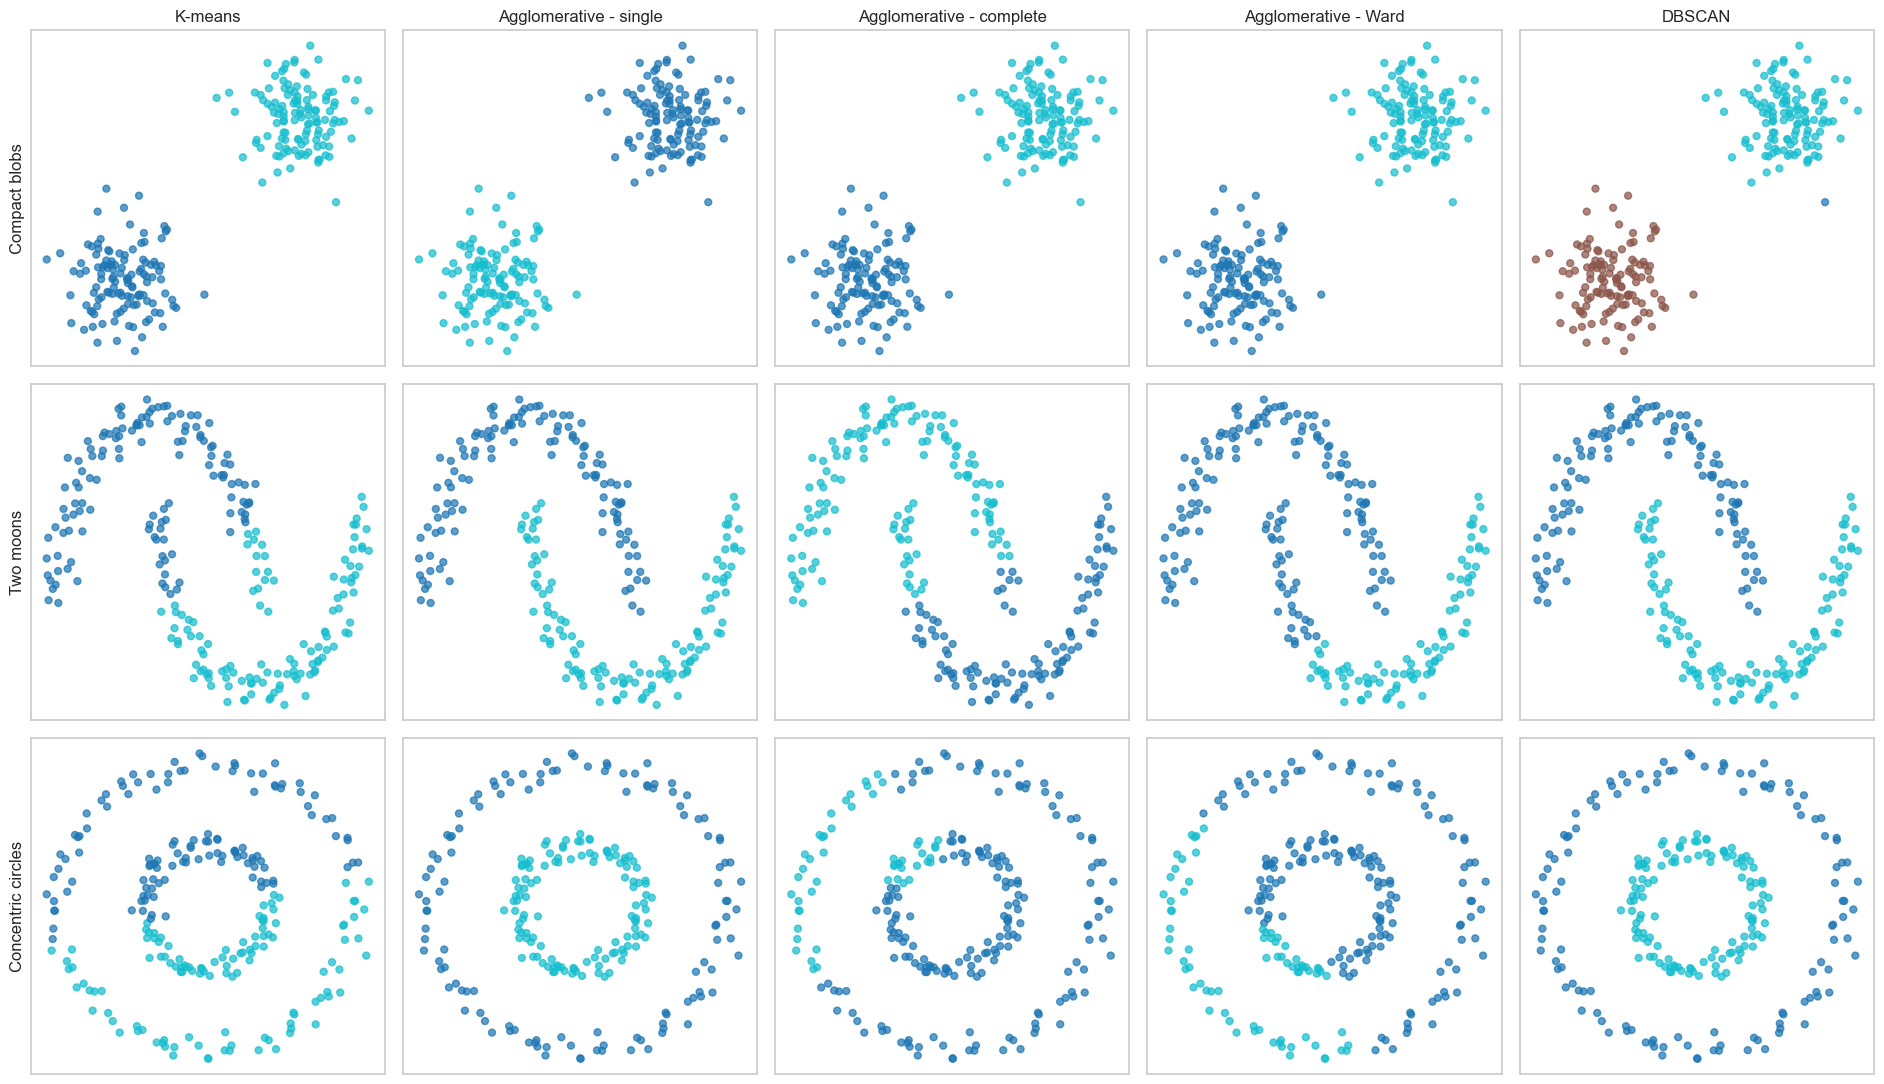

In [15]:
method_order = [
    "K-means",
    "Agglomerative - single",
    "Agglomerative - complete",
    "Agglomerative - Ward",
    "DBSCAN",
]

fig, axes = plt.subplots(
    len(toy_sets),
    len(method_order),
    figsize=(19, 11),
)

for row_index, (dataset_name, (X, _)) in enumerate(toy_sets.items()):
    for column_index, method_name in enumerate(method_order):
        axis = axes[row_index, column_index]
        labels = comparison_labels[(dataset_name, method_name)]

        axis.scatter(
            X[:, 0],
            X[:, 1],
            c=labels,
            cmap="tab10",
            s=25,
            alpha=0.72,
        )

        if row_index == 0:
            axis.set_title(method_name)

        if column_index == 0:
            axis.set_ylabel(dataset_name)

        axis.set_xticks([])
        axis.set_yticks([])

plt.tight_layout()
plt.show()

### Activity 5 - Build an evidence-based recommendation

For each dataset, choose the method you would recommend.

| Dataset | Recommended method | Visual evidence | Numerical evidence | Limitation |
|---|---|---|---|---|
| Compact blobs |  |  |  |  |
| Two moons |  |  |  |  |
| Concentric circles |  |  |  |  |

Then answer:

1. Why can the silhouette score favour a visually incorrect compact partition?
2. Why is ARI available in this experiment but usually unavailable in a real clustering task?
3. What does this comparison teach about the phrase “best clustering algorithm”?

## 6. Real-world example: Wine measurements

We now use the built-in Wine dataset from scikit-learn.

Each row represents a wine sample. The features are chemical measurements.  

The dataset also contains a known cultivar category, but we will **not** use it to create clusters. A cultivar is a cultivated variety of grapevine. In this dataset, each wine sample belongs to one of three cultivars.

The cultivar will be revealed later only as an external audit.

In [16]:
wine = load_wine(as_frame=True)

wine_features = wine.data.copy()
wine_reference = wine.target.copy()

print("Rows, features:", wine_features.shape)
display(wine_features.head())
display(wine_features.describe().T[["mean", "std", "min", "max"]])

Rows, features: (178, 13)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


,mean,std,min,max
alcohol,13.000618,0.811827,11.03,14.83
malic_acid,2.336348,1.117146,0.74,5.80
ash,2.366517,0.274344,1.36,3.23
alcalinity_of_ash,19.494944,3.339564,10.60,30.00
magnesium,99.741573,14.282484,70.00,162.00
total_phenols,2.295112,0.625851,0.98,3.88
flavanoids,2.029270,0.998859,0.34,5.08
nonflavanoid_phenols,0.361854,0.124453,0.13,0.66
proanthocyanins,1.590899,0.572359,0.41,3.58
color_intensity,5.058090,2.318286,1.28,13.00


### Predict before preprocessing

1. Why is standardisation necessary here?
2. Which feature would dominate Euclidean distance without scaling?
3. Why should the cultivar label remain outside the clustering matrix?

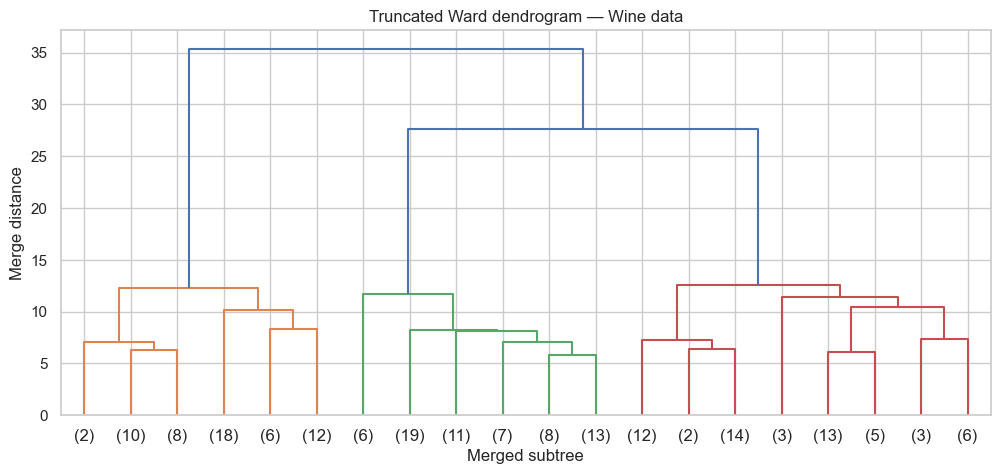

In [17]:
wine_scaler = StandardScaler()
X_wine_scaled = wine_scaler.fit_transform(wine_features)

wine_linkage = linkage(
    X_wine_scaled,
    method="ward",
)

plt.figure(figsize=(12, 5))
dendrogram(
    wine_linkage,
    truncate_mode="lastp",
    p=20,
    show_leaf_counts=True,
)
plt.title("Truncated Ward dendrogram — Wine data")
plt.xlabel("Merged subtree")
plt.ylabel("Merge distance")
plt.show()

### Activity 6 - Use the dendrogram as evidence

The dendrogram is truncated because 178 individual leaves would be difficult to read.

Answer:

1. Which candidate counts seem worth testing: 2, 3, 4, or more?
2. What merge-height evidence supports your candidates?
3. What information is hidden by the truncation?

### Compare three candidate methods

To keep the comparison interpretable:

- K-means uses `k=3`,
- Ward agglomerative clustering uses `3` clusters,
- DBSCAN uses a candidate density setting.

The aim is not to force all methods to return the same structure.

In [19]:
WINE_K = 3
WINE_EPS = 2.30
WINE_MIN_SAMPLES = 3

wine_methods = {
    "K-means": KMeans(
        n_clusters=WINE_K,
        n_init=30,
        random_state=42,
    ).fit_predict(X_wine_scaled),

    "Agglomerative - Ward": AgglomerativeClustering(
        n_clusters=WINE_K,
        linkage="ward",
    ).fit_predict(X_wine_scaled),

    "DBSCAN": DBSCAN(
        eps=WINE_EPS,
        min_samples=WINE_MIN_SAMPLES,
    ).fit_predict(X_wine_scaled),
}

wine_summary_rows = []

for method_name, labels in wine_methods.items():
    wine_summary_rows.append({
        "method": method_name,
        "clusters": count_clusters(labels),
        "noise points": int((labels == -1).sum()),
        "silhouette": silhouette_without_noise(
            X_wine_scaled,
            labels,
        ),
    })

wine_summary = pd.DataFrame(wine_summary_rows)
wine_summary.round(3)

,method,clusters,noise points,silhouette
0,K-means,3,0,0.285
1,Agglomerative - Ward,3,0,0.277
2,DBSCAN,3,32,0.225


### Before revealing the cultivar

Choose the method you currently prefer for exploratory grouping.

Your initial recommendation:

> I prefer __________ because __________.
>
> My evidence is __________.
>
> One concern is __________.

### Reading: Profiling Clusters in Standardised Units

The features were standardised before clustering. This means that each value is expressed relative to the mean of the whole dataset:

$$
z = \frac{x-\mu}{\sigma}
$$

where:

- $x$ is the original value,
- $\mu$ is the mean of the feature,
- $\sigma$ is its standard deviation.

When we compute the average value of a feature inside one cluster, we can interpret it as a **cluster profile**.

- A value close to **0** means that the cluster is close to the overall dataset average.
- A **positive** value means that the cluster average is above the overall mean.
- A **negative** value means that it is below the overall mean.
- The larger the absolute value, the more strongly that feature characterises the cluster.

For example, a cluster mean of:

$$
+1.2
$$

for `alcohol` means that the cluster has, on average, an alcohol value about **1.2 standard deviations above the dataset mean**.

This makes it possible to compare different features directly, even if they originally used different units.

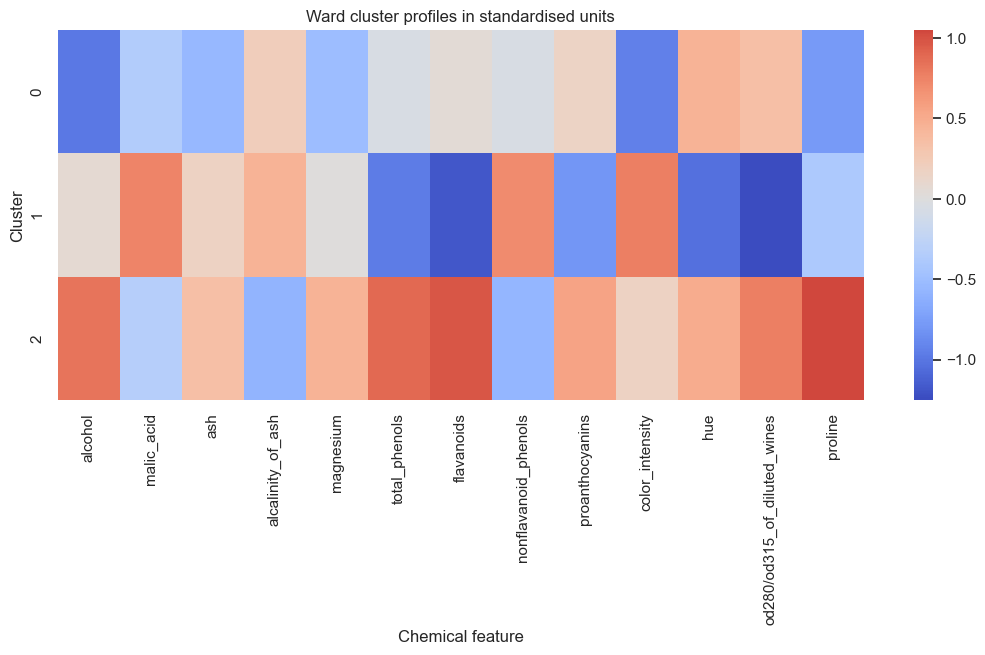

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
cluster,,,,,,,,,,,,,
0,-0.98,-0.36,-0.55,0.21,-0.50,-0.05,0.06,-0.05,0.17,-0.94,0.45,0.35,-0.78
1,0.08,0.75,0.17,0.45,0.01,-0.96,-1.19,0.71,-0.81,0.78,-1.04,-1.25,-0.39
2,0.83,-0.33,0.35,-0.59,0.45,0.89,0.98,-0.57,0.56,0.17,0.50,0.77,1.05


In [21]:
ward_labels = wine_methods["Agglomerative - Ward"]

wine_scaled_frame = pd.DataFrame(
    X_wine_scaled,
    columns=wine_features.columns,
)
wine_scaled_frame["cluster"] = ward_labels

ward_profile = wine_scaled_frame.groupby("cluster").mean()

plt.figure(figsize=(13, 4.8))
sns.heatmap(
    ward_profile,
    center=0,
    cmap="coolwarm",
    annot=False,
)
plt.title("Ward cluster profiles in standardised units")
plt.xlabel("Chemical feature")
plt.ylabel("Cluster")
plt.show()

ward_profile.round(2)

### Activity 7 — Interpret one real-data cluster

Choose one Ward cluster and write three sentences:

1. identify two or three features with strong deviations,
2. describe the cluster without inventing a causal story,
3. state one important within-cluster detail that the mean profile hides.

**Your interpretation:**

### External audit: reveal the cultivar categories

The cultivar was not used during clustering. We now use it only to ask whether the partitions correspond to this known external grouping.

A high ARI is useful evidence for this particular external reference, but it does not automatically prove that the method is best for every analytical purpose.

In [28]:
wine_external_rows = []

for method_name, labels in wine_methods.items():
    wine_external_rows.append({
        "method": method_name,
        "ARI against cultivar": adjusted_rand_score(
            wine_reference,
            labels,
        ),
    })

wine_external = pd.DataFrame(wine_external_rows)
wine_external.round(3)

,method,ARI against cultivar
0,K-means,0.897
1,Agglomerative - Ward,0.790
2,DBSCAN,0.399


### Verification checkpoint

1. Did the external audit support or weaken your initial recommendation?
2. Which conclusion should you revise?
3. Why would it still be incorrect to say that the cultivar labels are the only possible “true” clustering?

## 7. Assessed task - Method-selection memo

You are preparing a short recommendation for a colleague who wants exploratory groups in the Wine data.

Use the prepared results and perform **one additional comparison**:

- change `WINE_EPS` to one other defensible value, **or**
- change the agglomerative linkage, **or**
- test one additional cluster count suggested by the dendrogram.

Submit a concise memo containing:

1. **Question:** What grouping decision are you evaluating?
2. **Methods compared:** At least two methods or parameter settings.
3. **Evidence:** One visual and one numerical result.
4. **Recommendation:** A method and parameters.
5. **Cluster interpretation:** A short evidence-based description of one cluster.
6. **Limitation:** One reason the recommendation may not transfer to another dataset or purpose.
7. **AI note:** If AI was used, state one question it asked and one claim you independently verified.

In [ ]:
# Change ONE clearly marked setting and rerun the comparison.

ALTERNATIVE_EPS = 2.50
ALTERNATIVE_LINKAGE = "complete"
ALTERNATIVE_K = 4

# Option A: alternative DBSCAN
alternative_dbscan = DBSCAN(
    eps=ALTERNATIVE_EPS,
    min_samples=WINE_MIN_SAMPLES,
).fit_predict(X_wine_scaled)

# Option B: alternative agglomerative linkage
alternative_agglomerative = AgglomerativeClustering(
    n_clusters=ALTERNATIVE_K,
    linkage=ALTERNATIVE_LINKAGE,
).fit_predict(X_wine_scaled)

additional_comparison = pd.DataFrame([
    {
        "setting": f"DBSCAN eps={ALTERNATIVE_EPS}",
        "clusters": count_clusters(alternative_dbscan),
        "noise points": int((alternative_dbscan == -1).sum()),
        "silhouette": silhouette_without_noise(
            X_wine_scaled,
            alternative_dbscan,
        ),
        "ARI against cultivar": adjusted_rand_score(
            wine_reference,
            alternative_dbscan,
        ),
    },
    {
        "setting": (
            f"Agglomerative {ALTERNATIVE_LINKAGE}, "
            f"k={ALTERNATIVE_K}"
        ),
        "clusters": count_clusters(alternative_agglomerative),
        "noise points": int((alternative_agglomerative == -1).sum()),
        "silhouette": silhouette_without_noise(
            X_wine_scaled,
            alternative_agglomerative,
        ),
        "ARI against cultivar": adjusted_rand_score(
            wine_reference,
            alternative_agglomerative,
        ),
    },
])

additional_comparison.round(3)

### Your method-selection memo

**Question:**  

**Methods and settings compared:**  

**Visual evidence:**  

**Numerical evidence:**  

**Recommendation:**  

**Interpretation of one cluster:**  

**Limitation:**  

**Optional verified AI note:**

# End-of-lab self-check

Before finishing, check that you can:

- [ ] explain how agglomerative clustering builds a hierarchy,
- [ ] read merge height on a dendrogram,
- [ ] explain what changes when a dendrogram cut moves,
- [ ] distinguish single, complete, and Ward linkage,
- [ ] explain `eps` and `min_samples`,
- [ ] distinguish core, border, and noise points,
- [ ] identify fragmentation and merging in DBSCAN,
- [ ] explain why silhouette alone may be misleading,
- [ ] recommend a method based on geometry, density, noise, and evidence,
- [ ] revise an interpretation after questions without copying an AI answer.

Exercise 5 will move from unsupervised learning to optimisation and linear models.